In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

In [11]:
def add_box(ax, center, width, height, text, fontsize=10, fc="white"):
    """
    Helper to draw a rounded rectangle with centered text.
    """
    x, y = center
    ll = (x - width/2, y - height/2)
    box = FancyBboxPatch(
        ll, width, height,
        boxstyle="round,pad=0.2,rounding_size=0.15",
        linewidth=1.5, edgecolor="black", facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
    return box

def add_arrow(ax, start, end, text=None, fontsize=9, yoffset=0.0):
    """
    Helper to draw an arrow from start to end, optionally with a label.
    """
    ax.annotate(
        "",
        xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )
    if text is not None:
        mid = ((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + yoffset)
        ax.text(mid[0], mid[1], text, ha="center", va="center", fontsize=fontsize)

def make_pipeline_figure(savepath=None):
    """
    Make a schematic pipeline / flowchart figure for the SBI + D_KL idea.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    # Boxes
    box_w, box_h = 1.6, 0.9

    # CMB data (left)
    cmb_box = add_box(ax, (1.2, 3.0), box_w, box_h,
                      "CMB data\n(e.g. maps / spectra)", fontsize=9)

    # Splits
    splitA_box = add_box(ax, (3.0, 4.1), box_w, box_h,
                         "Split A\n(e.g. Mon/Wed/Fri)", fontsize=9)
    splitB_box = add_box(ax, (3.0, 1.9), box_w, box_h,
                         "Split B\n(e.g. Tue/Thu/Sat)", fontsize=9)

    # SBI pipelines
    sbiA_box = add_box(ax, (5.0, 4.1), box_w, box_h,
                       "SBI pipeline\n(NPE)", fontsize=9)
    sbiB_box = add_box(ax, (5.0, 1.9), box_w, box_h,
                       "SBI pipeline\n(NPE)", fontsize=9)

    # Posteriors
    postA_box = add_box(ax, (7.0, 4.1), box_w, box_h,
                        r"Posterior $p(\theta\,|\,\mathrm{Split\,A})$", fontsize=9)
    postB_box = add_box(ax, (7.0, 1.9), box_w, box_h,
                        r"Posterior $p(\theta\,|\,\mathrm{Split\,B})$", fontsize=9)

    # D_KL box
    dkl_text = (
        r"Compute divergence $D_{\mathrm{KL}}$"
        "\nbetween posteriors"
        "\n\nsmall: consistent / no evidence for systematics"
        "\nlarge: evidence for systematics"
    )
    dkl_box = add_box(ax, (9.0, 3.0), 2.4, 1.6, dkl_text, fontsize=8.5, fc="#f0f0ff")

    # Arrows
    add_arrow(ax, (cmb_box.get_x() + cmb_box.get_width(), 3.0),
              (splitA_box.get_x(), 4.1),
              text="split", yoffset=0.2)
    add_arrow(ax, (cmb_box.get_x() + cmb_box.get_width(), 3.0),
              (splitB_box.get_x(), 1.9),
              text="split", yoffset=-0.2)

    add_arrow(ax, (splitA_box.get_x() + splitA_box.get_width(), 4.1),
              (sbiA_box.get_x(), 4.1),
              text="train + infer", yoffset=0.2)
    add_arrow(ax, (splitB_box.get_x() + splitB_box.get_width(), 1.9),
              (sbiB_box.get_x(), 1.9),
              text="train + infer", yoffset=-0.2)

    add_arrow(ax, (sbiA_box.get_x() + sbiA_box.get_width(), 4.1),
              (postA_box.get_x(), 4.1))
    add_arrow(ax, (sbiB_box.get_x() + sbiB_box.get_width(), 1.9),
              (postB_box.get_x(), 1.9))

    add_arrow(ax, (postA_box.get_x() + postA_box.get_width(), 4.1),
              (dkl_box.get_x(), 3.5))
    add_arrow(ax, (postB_box.get_x() + postB_box.get_width(), 1.9),
              (dkl_box.get_x(), 2.5))

    ax.set_title(
        "Schematic pipeline: SBI on CMB data splits + divergence-based consistency test",
        fontsize=12
    )

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, ax

# Example usage:
# fig, ax = make_pipeline_figure()
# plt.show()
# fig.savefig("pipeline_schematic.pdf", dpi=300, bbox_inches="tight")


In [12]:
def make_posterior_overlap_figure(savepath=None, random_seed=42):
    """
    Make a toy 'corner-like' figure showing overlapping vs shifted posteriors
    from two splits, with approximate D_KL values in the titles.
    """
    rng = np.random.default_rng(random_seed)

    n_samples = 3000

    # Common covariance (correlated parameters)
    cov = np.array([[1.0, 0.6],
                    [0.6, 1.0]])

    # Case 1: consistent (same mean)
    meanA_consistent = np.array([0.0, 0.0])
    meanB_consistent = np.array([0.05, -0.03])  # tiny shift

    # Case 2: mismatched (clear systematic)
    meanA_mismatch = np.array([0.0, 0.0])
    meanB_mismatch = np.array([1.2, -0.3])      # noticeable shift

    # Draw samples
    A_cons = rng.multivariate_normal(meanA_consistent, cov, size=n_samples)
    B_cons = rng.multivariate_normal(meanB_consistent, cov, size=n_samples)

    A_mis = rng.multivariate_normal(meanA_mismatch, cov, size=n_samples)
    B_mis = rng.multivariate_normal(meanB_mismatch, cov, size=n_samples)

    # Analytic D_KL for equal covariances:
    # D_KL(N(m1,Σ) || N(m2,Σ)) = 0.5 * (m2 - m1)^T Σ^{-1} (m2 - m1)
    cov_inv = np.linalg.inv(cov)

    def kl_same_cov(m1, m2):
        diff = m2 - m1
        return 0.5 * diff.T @ cov_inv @ diff

    dkl_cons = kl_same_cov(meanA_consistent, meanB_consistent)
    dkl_mis = kl_same_cov(meanA_mismatch, meanB_mismatch)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    (ax11, ax12), (ax21, ax22) = axes

    # --- Row 1: consistent ---

    # 2D scatter
    ax11.scatter(A_cons[:, 0], A_cons[:, 1], s=4, alpha=0.3, label="Split A")
    ax11.scatter(B_cons[:, 0], B_cons[:, 1], s=4, alpha=0.3, label="Split B")
    ax11.set_xlabel(r"$\theta_1$")
    ax11.set_ylabel(r"$\theta_2$")
    ax11.set_title(r"Consistent Splits - Small $D_{\mathrm{KL}}$ " % dkl_cons)
    ax11.legend(loc="upper right", fontsize=8)

    # 1D marginal of theta_1
    bins = np.linspace(-3, 3, 40)
    ax12.hist(A_cons[:, 0], bins=bins, density=True, alpha=0.5, label="Split A")
    ax12.hist(B_cons[:, 0], bins=bins, density=True, alpha=0.5, label="Split B")
    ax12.set_xlabel(r"$\theta_1$")
    ax12.set_ylabel("Density")
    ax12.set_title("1D Marginal, Consistent Case")
    ax12.legend(fontsize=8)

    # --- Row 2: mismatched ---

    ax21.scatter(A_mis[:, 0], A_mis[:, 1], s=4, alpha=0.3, label="Split A")
    ax21.scatter(B_mis[:, 0], B_mis[:, 1], s=4, alpha=0.3, label="Split B")
    ax21.set_xlabel(r"$\theta_1$")
    ax21.set_ylabel(r"$\theta_2$")
    ax21.set_title(r"Inconsistent Splits - Large $D_{\mathrm{KL}}$ " % dkl_mis)
    ax21.legend(loc="upper right", fontsize=8)

    bins2 = np.linspace(-3, 3, 40)
    ax22.hist(A_mis[:, 0], bins=bins2, density=True, alpha=0.5, label="Split A")
    ax22.hist(B_mis[:, 0], bins=bins2, density=True, alpha=0.5, label="Split B")
    ax22.set_xlabel(r"$\theta_1$")
    ax22.set_ylabel("density")
    ax22.set_title("1D Marginal, Inconsistent Case")
    ax22.legend(fontsize=8)

    fig.suptitle("Toy posterior overlap vs mismatch for two CMB data splits", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, axes

# Example:
# fig, axes = make_posterior_overlap_figure()
# plt.show()
# fig.savefig("posterior_overlap_schematic.pdf", dpi=300, bbox_inches="tight")


In [13]:
def make_dkl_null_hist_figure(
    n_mc=5000, n_per_split=1000, observed_delta_mu=0.4,
    savepath=None, random_seed=123
):
    """
    Toy 1D example: distribution of D_KL between two posterior Gaussians
    under a null hypothesis that data for both splits come from the same
    N(0,1) generating process.

    We approximate posteriors by N(mean_hat, 1), and compute D_KL analytically:
        D_KL = 0.5 * (mu1 - mu2)^2
    for equal unit variance.
    """
    rng = np.random.default_rng(random_seed)

    dkl_values = []

    for _ in range(n_mc):
        # Data from common N(0, 1)
        x1 = rng.normal(loc=0.0, scale=1.0, size=n_per_split)
        x2 = rng.normal(loc=0.0, scale=1.0, size=n_per_split)

        mu1 = x1.mean()
        mu2 = x2.mean()

        # D_KL between N(mu1,1) and N(mu2,1)
        dkl = 0.5 * (mu1 - mu2) ** 2
        dkl_values.append(dkl)

    dkl_values = np.array(dkl_values)

    # Example "observed" value from a larger shift in the means
    dkl_obs = 0.5 * (observed_delta_mu ** 2)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(dkl_values, bins=40, density=True, alpha=0.7)
    ax.axvline(dkl_obs, linestyle="--", linewidth=2)

    ax.set_xlabel(r"$D_{\mathrm{KL}}$")
    ax.set_ylabel("density")
    ax.set_title(
        r"Toy null distribution of $D_{\mathrm{KL}}$ for two splits"
        "\n(null: same data-generating process)"
    )

    # Annotate observed value
    ymax = ax.get_ylim()[1]
    ax.text(dkl_obs, 0.95 * ymax,
            r"example observed $D_{\mathrm{KL}}$",
            rotation=90, va="top", ha="right", fontsize=9)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, ax

# Example:
# fig, ax = make_dkl_null_hist_figure()
# plt.show()
# fig.savefig("dkl_null_histogram.pdf", dpi=300, bbox_inches="tight")


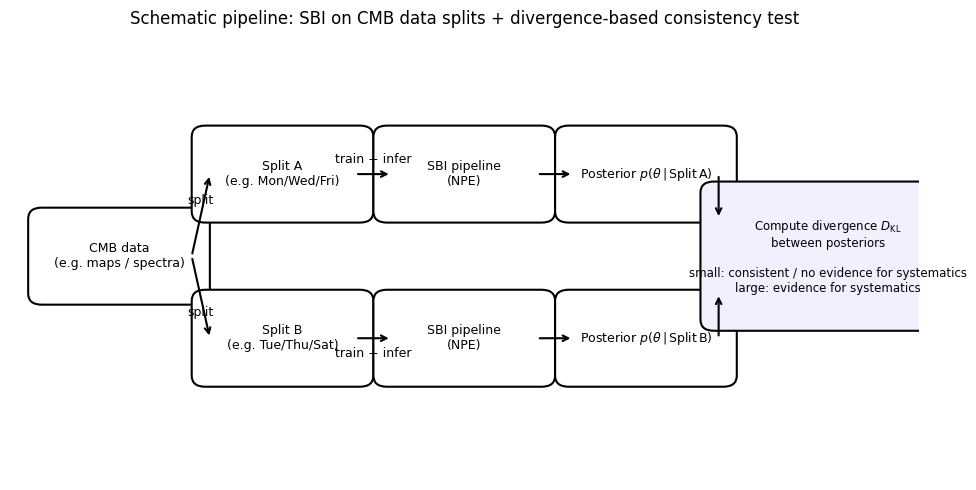

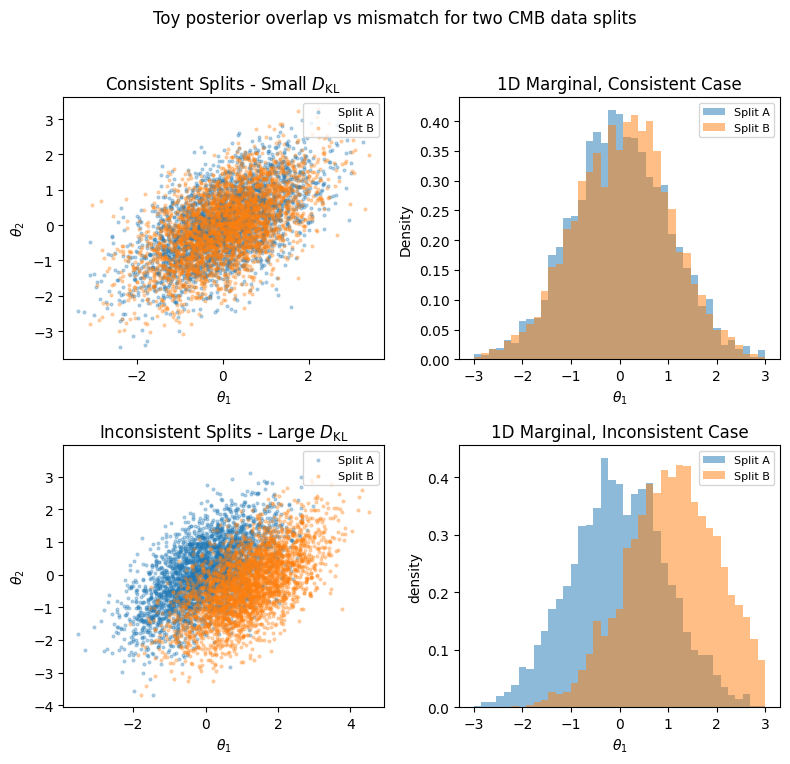

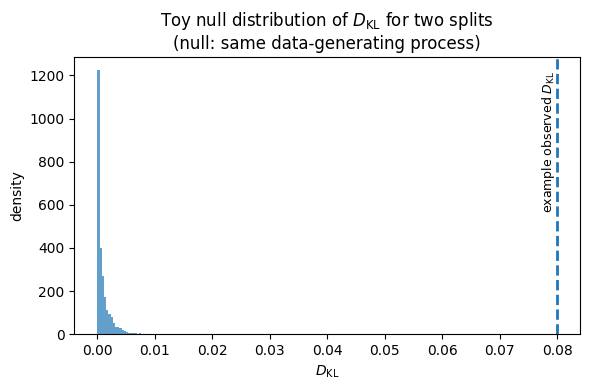

In [14]:
# 1) Pipeline / flowchart
fig, ax = make_pipeline_figure()
fig.savefig("fig1_pipeline_schematic.pdf", dpi=300, bbox_inches="tight")

# 2) Posterior overlap vs mismatch
fig2, axes2 = make_posterior_overlap_figure()
fig2.savefig("fig2_posterior_overlap_schematic.pdf", dpi=300, bbox_inches="tight")

# 3) Null distribution of D_KL
fig3, ax3 = make_dkl_null_hist_figure()
fig3.savefig("fig3_dkl_null_distribution.pdf", dpi=300, bbox_inches="tight")


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_cmb_flat(DlTT, ell, N=256, pix_size_arcmin=5.0, random_seed=0):
    """
    Simulate a Gaussian CMB temperature map on a flat patch using a given DlTT(ell).

    Parameters
    ----------
    DlTT : array, shape (n_ell,)
        D_ell^TT values (μK^2), typically from CAMB: D_ell = ell*(ell+1) C_ell / (2π)
    ell : array, shape (n_ell,)
        Multipole values corresponding to DlTT.
    N : int
        Number of pixels on a side (N x N map).
    pix_size_arcmin : float
        Pixel size in arcminutes.
    random_seed : int
        RNG seed for reproducibility.

    Returns
    -------
    cmb_map : array, shape (N, N)
        Simulated CMB temperature map in μK.
    """
    rng = np.random.default_rng(random_seed)

    # Convert Dl -> Cl, handle ell=0,1 safely
    ell = np.asarray(ell)
    DlTT = np.asarray(DlTT)
    ClTT = np.zeros_like(DlTT)
    mask = ell > 1
    ClTT[mask] = DlTT[mask] * 2.0 * np.pi / (ell[mask] * (ell[mask] + 1.0))

    # Pixel size in radians
    pix_size_rad = (pix_size_arcmin / 60.0) * np.pi / 180.0
    # Box size (radians)
    L = N * pix_size_rad

    # Fourier wavenumbers (rad^-1)
    kx = 2.0 * np.pi * np.fft.fftfreq(N, d=pix_size_rad)
    ky = 2.0 * np.pi * np.fft.fftfreq(N, d=pix_size_rad)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    ell_grid = np.sqrt(KX**2 + KY**2)  # flatsky: ell ≈ |k| (in rad^-1)

    # Interpolate Cl onto this grid
    Cl_interp = np.interp(ell_grid, ell, ClTT, left=0.0, right=0.0)

    # Draw complex Gaussian Fourier modes with variance = Cl/2 per real/imag component
    # Note: zero mode gets zero power (Cl=0 there anyway).
    std = np.sqrt(Cl_interp / 2.0)
    real_part = rng.normal(scale=std)
    imag_part = rng.normal(scale=std)
    fourier_modes = real_part + 1j * imag_part

    # Enforce Hermitian symmetry so the map is real
    fourier_modes[0, 0] = 0.0  # safety
    fourier_modes = (fourier_modes + np.conj(np.flip(np.flip(fourier_modes, 0), 1))) / 2.0

    # Inverse FFT to real space
    cmb_map = np.fft.ifft2(fourier_modes).real

    # Normalisation: the variance of the map should roughly match the total power.
    # For schematic purposes we can just rescale to μK-level fluctuations.
    cmb_map -= np.mean(cmb_map)
    cmb_map *= 1e5  # scale to ~100 μK-ish fluctuations

    return cmb_map


In [16]:
# Suppose from your CAMB notebook you already have ell, DlTT arrays:
# ell = results['ell']          # example
# DlTT = results['DlTT']        # example
# Toy DlTT ~ ell^(-0.8) just to get the right "look"
ell = np.arange(2, 3000)
DlTT = 1e3 * (ell / 100.)**(-0.8)

cmb_map = simulate_cmb_flat(DlTT, ell, N=256, pix_size_arcmin=5.0, random_seed=0)

cmb_map = simulate_cmb_flat(DlTT, ell, N=256, pix_size_arcmin=5.0, random_seed=0)


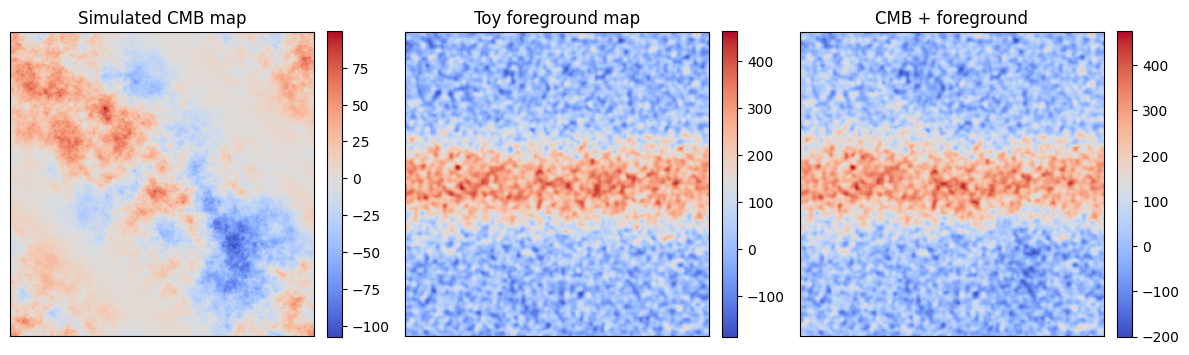

: 

In [ ]:
def simulate_foreground(N=256, amplitude=300.0, stripe_width_fraction=0.2,
                        small_scale_amp=50.0, random_seed=1):
    """
    Make a toy CMB foreground map:
    - smooth stripe across the middle (galactic plane-like)
    - plus small-scale correlated fluctuations.

    Parameters
    ----------
    N : int
        Number of pixels per side.
    amplitude : float
        Peak amplitude of the large-scale stripe (μK).
    stripe_width_fraction : float
        Stripe half-width as a fraction of the map (e.g. 0.2 = 20% of map).
    small_scale_amp : float
        Overall amplitude of small-scale component (μK).
    random_seed : int
        RNG seed.

    Returns
    -------
    fg_map : array, shape (N, N)
        Toy foreground map in μK.
    """
    rng = np.random.default_rng(random_seed)

    # Large-scale stripe in the y-direction
    y = np.linspace(-1.0, 1.0, N)
    Y = np.tile(y, (N, 1)).T  # shape (N, N)
    sigma = stripe_width_fraction
    stripe = np.exp(-0.5 * (Y / sigma) ** 2)

    # Normalise stripe to have max=1 then scale to desired amplitude
    stripe = amplitude * stripe / np.max(stripe)

    # Small-scale correlated fluctuations: start with white noise..
    noise = rng.normal(size=(N, N))

    # ..and smooth it in Fourier space by applying a low-pass filter
    kx = np.fft.fftfreq(N)
    ky = np.fft.fftfreq(N)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    k2 = KX**2 + KY**2

    # Filter: suppress very high-k modes, keep low/moderate k
    filter_2d = np.exp(-k2 / 0.02)

    noise_ft = np.fft.fft2(noise)
    noise_ft_filtered = noise_ft * filter_2d
    small_scale = np.fft.ifft2(noise_ft_filtered).real

    # Normalise and scale
    small_scale -= np.mean(small_scale)
    small_scale /= (np.std(small_scale) + 1e-8)
    small_scale *= small_scale_amp

    fg_map = stripe + small_scale
    return fg_map

# 1) Get a CMB map
# Either from real CAMB DlTT/ell, or toy power-law as shown above.
ell = np.arange(2, 3000)
DlTT = 1e3 * (ell / 100.)**(-0.8)
cmb_map = simulate_cmb_flat(DlTT, ell, N=256, pix_size_arcmin=5.0, random_seed=0)

# 2) Get a toy foreground map
fg_map = simulate_foreground(N=256, amplitude=300.0,
                             stripe_width_fraction=0.2,
                             small_scale_amp=50.0,
                             random_seed=1)

# 3) Combine
cmb_plus_fg = cmb_map + fg_map

# 4) Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(cmb_map, origin="lower", cmap="coolwarm")
axes[0].set_title("Simulated CMB map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(fg_map, origin="lower", cmap="coolwarm")
axes[1].set_title("Toy foreground map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(cmb_plus_fg, origin="lower", cmap="coolwarm")
axes[2].set_title("CMB + foreground")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
# Save for the report:
# fig.savefig("cmb_foreground_example.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Round 1: Market Making on Dice Rolls

This round focused on quantitative reasoning and market-making principles under evolving conditions. You were asked to create and manage markets for a series of events based on dice rolls.

* **Part 1: Single Die Markets**
    1.  **6-Sided Die:** Make a market on the outcome of a single roll of a fair 6-sided die. The market must be **1-point wide**. A key challenge was to determine the appropriate **market size**.
    2.  **8-Sided Die:** Make a market on the outcome of an 8-sided die.
    3.  **10-Sided Die:** Make a market on the outcome of a 10-sided die.

* **Part 2: Sum of Dice**
    1.  Make a **1-point wide** market on the **sum of the outcomes** of the three dice mentioned above (6-sided, 8-sided, and 10-sided). You were responsible for setting the market size.

* **Part 3: Conditional Probability Market**
    1.  **Setup:** A die is chosen at random from a set of six dice: a 4-sided, 6-sided, 8-sided, 10-sided, 12-sided, and 20-sided die. Each die has a $1/6$ probability of being selected.
    2.  **Task:** After the first roll reveals which die is in play, you must immediately make a market on the outcome of the **second roll** of that specific die.

**Note:** In each scenario, you were required to manage your Profit and Loss (PNL) as an opponent actively traded against your markets.

***

## Round 2: Market Making on Card Games

This round tested your ability to calculate probabilities and make markets on complex, multi-variable events, while also assessing your strategic decision-making.

* **Part 1: Core Market Making**
    1.  **Setup:** Four cards are drawn from a standard 52-card deck.
    2.  **Task:** Make markets on the following propositions (the width of the markets was provided):
        * The **sum** of the numerical values of the four cards.
        * The **square of the number of red cards** drawn.
        * A derived value, described as "$24$ divided by a certain property of the cards."

* **Part 2: Dynamic Adjustments & Hedging**
    1.  You had to continuously manage your positions by **skewing** markets and **hedging** your risk as an opponent traded against every market you made.

* **Part 3: Strategic Decision-Making**
    1.  You were presented with options and had to evaluate their expected value. For example:
        * "Would you pay 10 chips for the ability to choose one of the next four cards to be drawn?"
        * "Which specific card would you most want the next card to be?"

***

## Round 3: Game Theory & Behavioral Analysis

This was a complex game theory problem requiring data analysis, opponent modeling, and optimal betting strategy under uncertainty. The scenario was framed as the final round of the game show *Jeopardy*.

* **Part 1: The Game**
    1.  **Setup:** A three-player game involving yourself and two opponents (A and B, or other combinations).
    2.  **Capital:** Each player begins with a starting capital, drawn from a uniform distribution of $\$5000 \pm \$2000$ (i.e., $[\$3000, \$7000]$).
    3.  **Betting:** Players simultaneously decide how much of their capital to wager.
    4.  **Outcome:** If a player answers the question correctly, they win their wagered amount. If incorrect, they lose it. The player with the highest final capital wins the entire prize pool.
    5.  **Probabilities:** Your probability of answering correctly is $1/2$. Based on historical data, Player A's probability is $2/3$, and Player C's is $1/3$.

* **Part 2: Data Analysis & Strategy**
    1.  You were provided with a spreadsheet of **100 historical rounds** showing the betting behavior of Players A, B, and C.
    2.  Your primary task was to analyze this data, model your opponents' strategies, and formulate your own optimal betting decisions in rotating rounds against them.

* **Part 3: The "Tickets" Multiplier**
    1.  **Mechanic:** You could buy "tickets" to multiply your winnings. Winnings were converted to chips (e.g., \$5000 = 5 chips).
    2.  **Cost:** Tickets had an escalating cost: the first cost 3 chips, the second cost 4 chips, and the third cost 5 chips.
    3.  **Rollover Rule:** If you won a round, your purchased tickets would **roll over** to the next round at no cost. If you lost, the tickets were forfeited.
    4.  **Inflation:** The cost of all tickets increased by 1 chip every three rounds.

***

## Round 4: Behavioral Interview & Probability Brainteaser

This round combined a standard behavioral review with a challenging quantitative question.

* **Part 1: CV Review**
    1.  A discussion centered on your background and the details presented on your CV.

* **Part 2: The Decisive Vote Problem**
    1.  **Question:** "In a large election where the outcome is expected to be nearly 50/50, what is the probability that your individual vote will be the **decisive vote** that changes the final result?"
    2.  **Expectation:** The problem required a rigorous, quantitative approach involving making and stating assumptions, modeling the scenario with statistical distributions (e.g., Normal or Uniform), and potentially using diagrams to illustrate your reasoning.
